# NLP — 12. Sequence-to-Sequence Models

Now we're moving from **word-level representations** toward models that work with **entire sequences.**

The main idea is simple:

> A **Sequence-to-Sequence (Seq2Seq) model** takes one sequence as input and produces another sequence as output.

## 1. What is a sequence?

In NLP, a sequence is simply an ordered collection of tokens/words.

For example:
`"I love Python"`

is a sequence:

Another sequence could be: `"Je suis étudiant"`

The words have an order, and that order matters.

## 2. What is a Sequence-to-Sequence?

A Seq2Seq model maps:

For example:

### Machine Translation

Both the input and output are sequences.

### Text Summarization

### Question Answering / Response Generation

So Seq2Seq isn't limited to translation.

## 3. Why was Seq2Seq needed?

Earlier NLP models often had a fixed relationship between input and output.

For example:

That's fine for classification.

But translation is different.

The number of input and output words doesn't have to be the same.

For example:

So we need a model capable of:

- reading a sequence
- understanding it
- generating another sequence
- producing the output one token at a time

This led to **Seq2Seq architectures.**

## 4. The basic Seq2Seq architecture

The classic Seq2Seq architecture consists of two major components:

Visualize it like this:

For translation:

The encoder and decoder have different jobs.

## 5. Encoder

The **encoder** reads the input sequence.

For: `"I love Pyhton"`

the encoder processes:

and creates an internal representation of the input.

Conceptually:

The encoder's job is therefore:

> **Understand/encode the input sequence into a representation that the decoder can use.**

## 6. Decoder

The decoder takes the representation from the encoder and generates the output sequence.

For example:

The decoder generally generates the output one token at a time.

So:

This is called **autoregressive generation.**

The next output token depends on the previously generated tokens.

## 7. Complete example

Let's use translation:

### Step 1 — Encoder

### Step 2 — Decoder starts generating

Then:

Then:

Then:

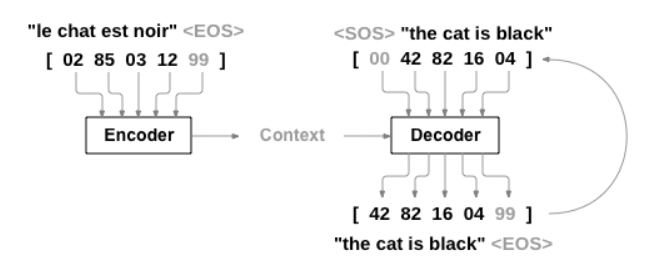

## 8. Why is the decoder generating one word at a time?

Because language generation is naturally sequential.

Suppose we want:
`"I love Python"`

After generating: `"I"`

the model needs to decide what comes next.

It might predict:
`"I love"`

Then:
`"I love Python"`

Then:
`END`

Each prediction uses what has already been generated.

## 9. Special tokens

You may encounter special tokens such as:

`<SOS>` **Start of Sequence**

Tells the decoder:

> Start generating.

`EOS` **End of Sequence**

Tells the decoder:

> The output is finished.

For example:

So the decoder knows when to begin and when to stop.

## 10. A major problem with early Seq2Seq models

Here's where things become interesting.

Suppose the input is very short:

It's relatively easy to encode.

But what about:

The encoder has to represent a **long sequence.**
    
The original Seq2Seq architecture often tried to compress the entire input into a **single fixed-size representation.**

Conceptually:

This creates a bottleneck.

## 11. The information bottleneck

Imagine trying to summarize an entire book into one tiny note.

Some information will inevitably be lost.

Similarly:

For short sequences, this can work reasonably well.
    
For long sequences, it becomes harder.
    
The decoder may not have access to all the information it needs.

This became known as a major limitation of early encoder-decoder Seq2Seq models.

## 12. And this leads directly to Attention

The solution was essentially:

> **Why force the decoder to rely on one fixed representation? Let it look back at the relevant parts of the input.**

That idea is **Attention.**

Instead of:

we move toward:

The decoder can determine:

> "Which parts of the input are important for generating this particular output token?"

For example, while translating a particular word, the decoder can focus more strongly on the corresponding part of the source sentence.

## 13. Seq2Seq evolution

This gives us a very important historical progression:

We're studying these concepts because modern LLMs didn't appear out of nowhere.

Each stage solved limitations of the previous stage.

## 14. Important terminology

Keep these terms clear:

### Sequence

An ordered series of tokens

`I love NLP`

### Encoder

Reads and represents the input sequence.

`Input → Encoder → Representation`

### Decoder

Generates the output sequence.

`Representation → Decoder → Output`

### Seq2Seq

The overall idea of mapping:

`Input sequence → Output sequence`

### Autoregressive generation

Generating output tokens sequentially, using previously generated tokens.

## ✅ The one thing to remember

If you remember only the core idea:

> **A Seq2Seq model converts one sequence into another using an encoder to process the input and a decoder to generate the output.**

And the major weakness of the early approach was:

> **Trying to compress a long input into one fixed representation created an information bottleneck.**

That problem is what motivates our next concepts.

**Next → NLP — 13. Encoder–Decoder Architecture**

We'll go one level deeper and understand **exactly what the encoder and decoder are doing,** including how RNN/LSTM-based Seq2Seq models process the sequence.

# NLP — 13. Encoder–Decoder Architecture

In the previous topic, we learned the basic idea of **Seq2Seq:**

Now let's understand **what actually happens inside the encoder and decoder.**

## 1. Why do we need an Encoder–Decoder?

Suppose we want to translate: `"I love machine learning"`

into: `"J'aime l'apprentissage automatique"`

The input and output:

- have different words
- have different lengths
- are in different languages

So we can't simply map:

Instead, we need a model that:

1. reads and understands the input
2. stores useful information about it
3. generates the output

That's the **Encoder–Decoder architecture.**

## 2. The basic architecture

Think of the encoder as the **reader** and the decoder as the **writer.**

> **Encoder:** "Let me understand the input."

> **Decoder:** "Now let me generate the required output."

## 3. Encoder: processing the input

Consider: `I love NLP`

After tokenization:

`I → love → NLP`

An RNN-based encoder processes these tokens one by one.

At each step, the encoder maintains a **hidden state.**

Conceptually:

Each hidden state contains information accumulated from the sequence processed so far.

So:

The final state contains a summary of the input.

## 4. What is a hidden state?

You have already encountered hidden states if you've studied RNNs.

A hidden state is essentially the model's **internal memory at a particular time step.**

For an RNN:

Mathematically, a simplified RNN is:

$$h_t = f(W_x x_t + W_h h_{t-1} + b)$$

where:
* $x_t$ = current input
* $h_{t-1}$ = previous hidden state
* $h_t$ = new hidden state
* $W_x, W_h$ = learnable weights
* $b$ = bias
* $f$ = activation function

You don't need to memorize this equation right now. The important idea is:

> **The current state depends on both the current input and what the model remembers from earlier inputs.**

## 5. Encoder's final representation

Suppose: 

and eventually produces:

In the simplest encoder-decoder architecture, the final hidden state is passed to the decoder.

This is sometimes called the **context vector** in classic Seq2Seq discussions.

## 6. Decoder: generating the output

Now the decoder receives the encoder's information.

Suppose we want: `J'aime le NLP`

The decoder doesn't produce the entire sentence simultaneously.

It generates tokens sequentially:

So:

## 7. How does the decoder know what to generate?

At each step, the decoder considers:

1. the encoder's representation
2. its previous hidden state
3. the previously generated token

Conceptually:

## 8. Autoregressive generation

This process is called **autoregressive generation.**
    
The decoder uses previously generated tokens to generate the next token.

In other words:

> **The output generated so far helps determine what comes next.**

This concept remains extremely important in modern language generation.

## 9. Training vs inference

There's an important distinction here.

**During training**
    
The model already knows the correct output.
    
For example:

The decoder can be given the correct previous token while learning.

This is called **teacher forcing.**

## 10. Teacher forcing

Suppose the correct output is:
`J'aime le NLP`

During training, we might do:

Notice something important.
    
When predicting `le`, we give the decoder the **correct previous word** `J'aime`, rather than forcing it to use its own potentially incorrect prediction.

This helps training become much more efficient.

## 11. During inference

When the model is actually being used, the correct answer isn't available.

So it has to use its own predictions.

So:

This difference is important in Seq2Seq models.

## 12. What does the decoder actually output?

The decoder doesn't directly output a word.

It typically produces a **probability distribution over the vocabulary.**

Suppose the vocabulary contains:

At one step, the decoder might produce:

The model then selects a token according to its decoding strategy.

So:

This is the same fundamental idea we'll see later in language models.

## 13. Complete example

<p align="center">
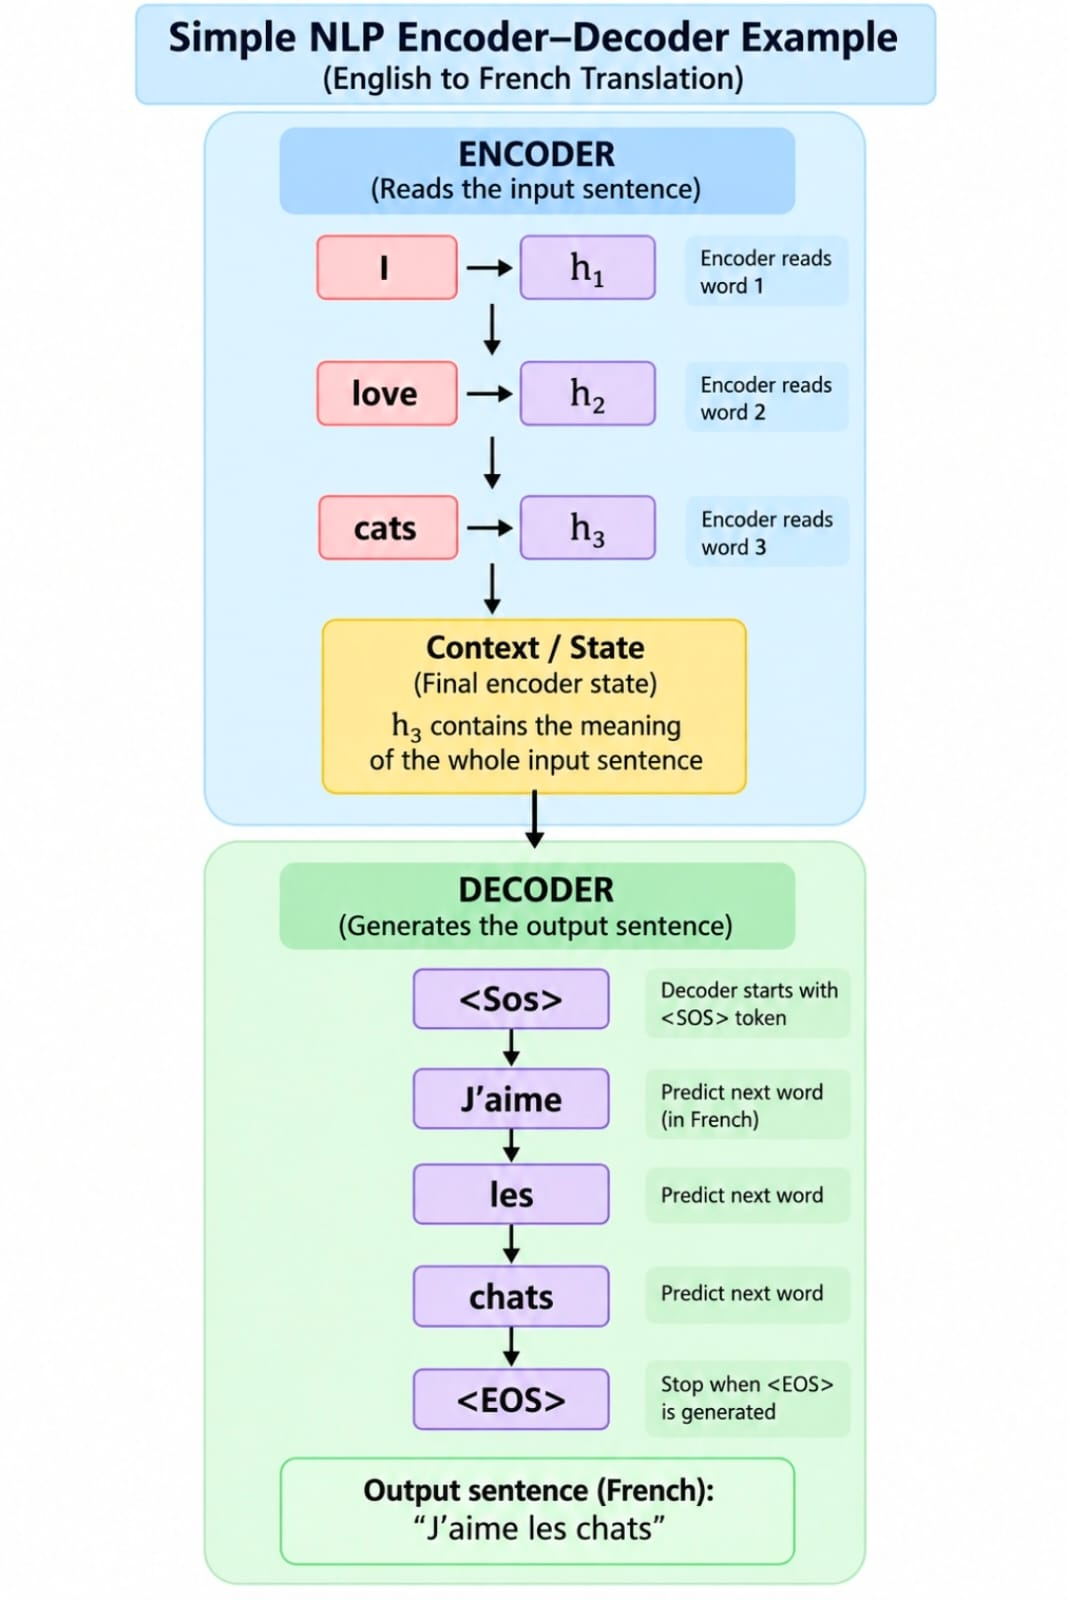
</p>

## 14. The major problem: the bottleneck

<p align="center">
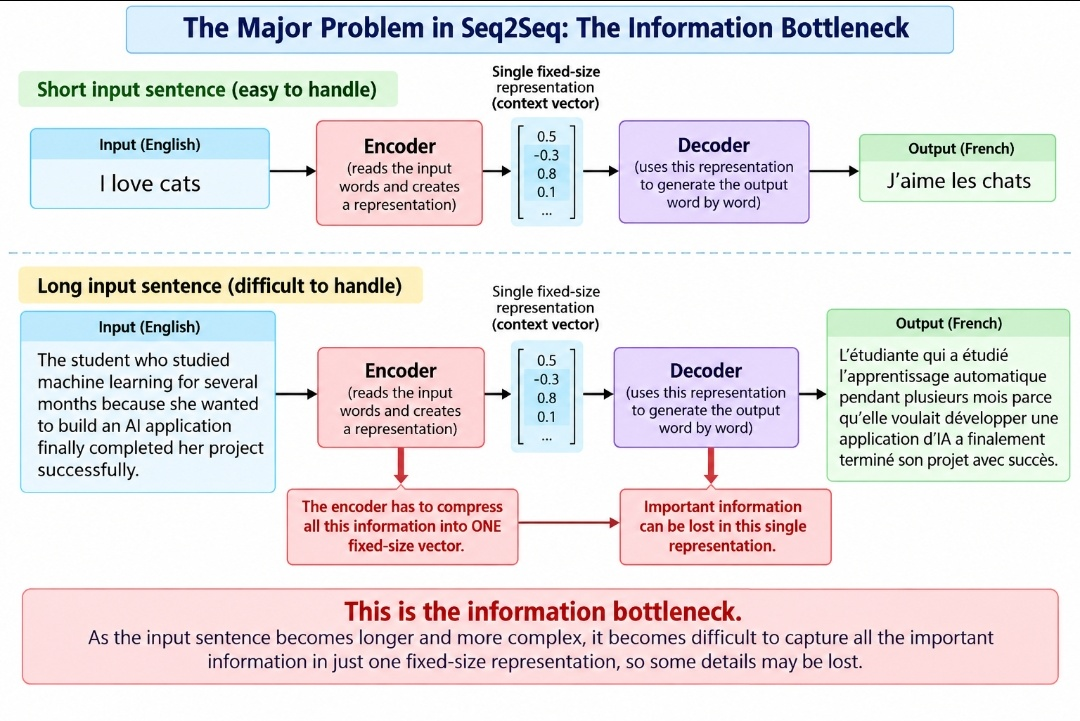
</p>

## 15. How Attention solves this

This is exactly why **Attention** became important.

Instead of forcing the decoder to rely only on one final representation:

we allow the decoder to access information from **different encoder states.**

The decoder can effectively say:

> "For the word I'm generating right now, which parts of the input should I pay more attention to?"

And **that is the bridge to our next major topic.**

## 16. Encoder–Decoder vs Seq2Seq

### 🧠 Seq2Seq = WHAT?

**Seq2Seq means:**

> **Sequence → Sequence**

It describes a **type of task/problem.**

Example:

Here:

That's Seq2Seq.

Other Seq2Seq tasks:

In [ ]:
English text → French text       |   Translation
Long article → Short summary     |   Summarization
Question → Answer                |      QA
Audio sequence → Text sequence   |  Speech recognition

### 🏗️ Encoder–Decoder = HOW?

Encoder–Decoder is an **architecture/design** used to perform a sequence-to-sequence task.

For example:

So the architecture is:

**Encoder → Decoder**

### 🔥 The easiest way to remember

Imagine you're building a house.

**Seq2Seq = What are you trying to build?**

> A house.

**Encoder–Decoder = How is the house designed/built?**

> Foundation → walls → roof.

Similarly:

## 17. Why this matters for modern GenAI

The encoder-decoder idea appears in many important NLP architectures.

For example:

And Transformer-based encoder-decoder models are still used for tasks such as translation and summarization.

Later, when we study LLMs, you'll also see architectures that use:

- **encoder-only** → e.g. BERT-style models
- **decoder-only** → GPT-style models
- **encoder-decoder** → T5-style models

So understanding this architecture now will make those distinctions much easier.

The key limitation:

**Next → NLP — 14. Attention**

This is the **most important concept in this part of the roadmap.** We'll first understand attention intuitively, then the actual mechanism, and eventually **Query, Key, Value and the attention formula.**

# RNN Fundamentals